# EDA do corpus grande sanitizado

Este notebook explora `data/large_sanitized/large_sanitized.jsonl`, com foco em estatísticas úteis para descrever o corpus no paper e apoiar decisões de amostragem/anotação.

As análises cobrem:

- volume e schema do JSONL;
- distribuição de comprimento dos relatos;
- distribuição por `assunto`;
- cobertura e distribuição dos metadados geográficos;
- sinais simples de qualidade textual;
- frequências de termos e bigramas;
- exemplos para inspeção qualitativa.

In [1]:
from pathlib import Path
import os
import json
import math
import re
import unicodedata
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("ggplot")

DATA_PATH = Path("../data/large_sanitized/large_sanitized.jsonl")
SUMMARY_PATH = Path("../data/large_sanitized/large_summary.json")

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)

DATA_PATH.resolve()

PosixPath('/home/ebezerra/ailab/nerdd/data/large_sanitized/large_sanitized.jsonl')

## Carregamento

O arquivo é JSONL. A célula abaixo carrega cada linha como um objeto e expande o bloco `_sanitization` para colunas com prefixo `sanitization_`.

In [2]:
def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(handle, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSONL at line {line_no}: {exc}") from exc
    return rows

rows = read_jsonl(DATA_PATH)
df = pd.json_normalize(rows, sep="_")

summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8")) if SUMMARY_PATH.exists() else {}

print(f"Linhas carregadas: {len(df):,}")
print(f"Colunas: {len(df.columns)}")
df.head(3)

Linhas carregadas: 184,493
Colunas: 11


,assunto,relato,logradouroLocal,bairroLocal,cidadeLocal,pontodeReferenciaLocal,_sanitization_status,_sanitization_reasons,_sanitization_row_index_1based,_sanitization_relato_length,_sanitization_normalized_relato_hash
0,Roubo carga/ veículo,"Dois moleques em uma moto estão tocando o terror em São Gonçalo, dois deram cobertura no assalto a um supermercado rede economia próximo a RJ nas próximidad...",Rj,Guaxindiba,são gonçalo,"rodovia RJ,",kept,[],1,271,ba4851f49ccc823f0a466c5f21d702eabeb86be3
1,Roubo carga/ veículo,"Traficantes do complexo Lins em posse do auto de placa KZN 6332,mesmo com upp na região os meliantes praticam assaltos na região da serra Grajaú-Jacarepaguá...",Rua Araújo Leitão,Lins de Vasconcelos,Rio de Janeiro,Quadra da Unidos do cabuçu!,kept,[],2,234,5f159be8ca0ee05ef1329ff2fec28edc4389c092
2,Homicídios,"Melícia da estrada da pedra,matando inocentes e destruindo famílias.\nDodô,felipe branco,e Sandro são alguns que comandam e matam pessoas de bem daquela reg...","estrada da pedra,proximo ao brizolao",cinco marias,rio de janeiro,,kept,[],3,212,7a9934e5a83bb1fae448eac418c2fb51b3be1c61


In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184493 entries, 0 to 184492
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype 
---  ------                                --------------   ----- 
 0   assunto                               184493 non-null  object
 1   relato                                184493 non-null  object
 2   logradouroLocal                       184493 non-null  object
 3   bairroLocal                           184493 non-null  object
 4   cidadeLocal                           184493 non-null  object
 5   pontodeReferenciaLocal                184493 non-null  object
 6   _sanitization_status                  184493 non-null  object
 7   _sanitization_reasons                 184493 non-null  object
 8   _sanitization_row_index_1based        184493 non-null  int64 
 9   _sanitization_relato_length           184493 non-null  int64 
 10  _sanitization_normalized_relato_hash  184493 non-null  object
dtypes: int64(2), 

## Resumo da sanitização

Quando `large_summary.json` estiver disponível, ele resume o corpus bruto, o corpus mantido e as razões de descarte/revisão.

In [4]:
if summary:
    display(pd.DataFrame([{
        "rows_total_raw": summary.get("rows_total"),
        "rows_kept": summary.get("rows_kept"),
        "rows_dropped_safe": summary.get("rows_dropped_safe"),
        "rows_flagged_review": summary.get("rows_flagged_review"),
        "kept_rate": summary.get("rows_kept", 0) / summary.get("rows_total", 1),
    }]))
    display(pd.Series(summary.get("reasons", {}), name="count").sort_values(ascending=False).to_frame())
else:
    print("Arquivo de resumo não encontrado.")

,rows_total_raw,rows_kept,rows_dropped_safe,rows_flagged_review,kept_rate
0,366854,184493,159888,22473,0.502906


,count
kept,184493
dropped_safe,159888
duplicate_normalized_relato,117043
duplicate_exact_relato,37314
flagged_review,22473
mojibake_suspected,18266
name_list_dump,3107
low_context_text,2958
looks_like_document,1567
short_low_context,1234


## Engenharia de atributos para EDA

As métricas abaixo são simples e interpretáveis: caracteres, palavras, linhas, presença de dígitos, URLs, proporção de caixa alta e pontuação.

In [5]:
WORD_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)
URL_RE = re.compile(r"https?://|www\.|\byoutu\.?be\b", flags=re.IGNORECASE)

def normalize_text(value) -> str:
    return value if isinstance(value, str) else ""

def word_count(text: str) -> int:
    return len(WORD_RE.findall(text))

def uppercase_ratio(text: str) -> float:
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)

def digit_ratio(text: str) -> float:
    if not text:
        return 0.0
    return sum(ch.isdigit() for ch in text) / len(text)

def punctuation_ratio(text: str) -> float:
    if not text:
        return 0.0
    return sum(unicodedata.category(ch).startswith("P") for ch in text) / len(text)

df["relato"] = df["relato"].map(normalize_text)
df["relato_chars"] = df["relato"].str.len()
df["relato_words"] = df["relato"].map(word_count)
df["relato_lines"] = df["relato"].str.count("\n") + 1
df["uppercase_ratio"] = df["relato"].map(uppercase_ratio)
df["digit_ratio"] = df["relato"].map(digit_ratio)
df["punctuation_ratio"] = df["relato"].map(punctuation_ratio)
df["has_url"] = df["relato"].str.contains(URL_RE, regex=True)

df[["relato", "relato_chars", "relato_words", "relato_lines", "uppercase_ratio", "digit_ratio", "punctuation_ratio", "has_url"]].head()

,relato,relato_chars,relato_words,relato_lines,uppercase_ratio,digit_ratio,punctuation_ratio,has_url
0,"Dois moleques em uma moto estão tocando o terror em São Gonçalo, dois deram cobertura no assalto a um supermercado rede economia próximo a RJ nas próximidad...",271,45,1,0.045455,0.014760,0.011070,False
1,"Traficantes do complexo Lins em posse do auto de placa KZN 6332,mesmo com upp na região os meliantes praticam assaltos na região da serra Grajaú-Jacarepaguá...",234,39,1,0.063158,0.017094,0.029915,False
2,"Melícia da estrada da pedra,matando inocentes e destruindo famílias.\nDodô,felipe branco,e Sandro são alguns que comandam e matam pessoas de bem daquela reg...",212,35,3,0.022857,0.000000,0.028302,False
3,"Bom dia, moro no bairro de tomazinho, meliantes estao roubando cargas e levando para o lugar chamado balanço da jaqueira.\nEles estao fechando as ruas com b...",289,47,3,0.016949,0.000000,0.024221,False
4,"Prezados,\n\nGostaria de relatar a presença de manifestantes em frente à secretaria de educação. Os funcionários estão ""acuados"" dentro do prédio.A interven...",236,35,3,0.020408,0.000000,0.025424,False


## Estatísticas descritivas de comprimento

In [6]:
length_stats = df[["relato_chars", "relato_words", "relato_lines"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T
length_stats

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
relato_chars,184493.0,310.315410,262.257564,20.0,42.0,77.0,105.0,167.0,245.0,372.0,559.0,736.0,1364.08,4774.0
relato_words,184493.0,48.367429,44.136301,1.0,7.0,12.0,16.0,25.0,37.0,57.0,89.0,120.0,228.00,885.0
relato_lines,184493.0,5.208382,6.277075,1.0,1.0,1.0,1.0,1.0,3.0,7.0,13.0,18.0,28.00,111.0


In [7]:
thresholds = [20, 50, 100, 250, 500, 1000, 2000, 5000]
pd.DataFrame({
    "threshold_chars": thresholds,
    "rows_ge_threshold": [(df["relato_chars"] >= t).sum() for t in thresholds],
    "share_ge_threshold": [(df["relato_chars"] >= t).mean() for t in thresholds],
})

,threshold_chars,rows_ge_threshold,share_ge_threshold
0,20,184493,1.000000
1,50,181452,0.983517
2,100,167799,0.909514
3,250,89684,0.486111
4,500,24175,0.131035
5,1000,4319,0.023410
6,2000,537,0.002911
7,5000,0,0.000000


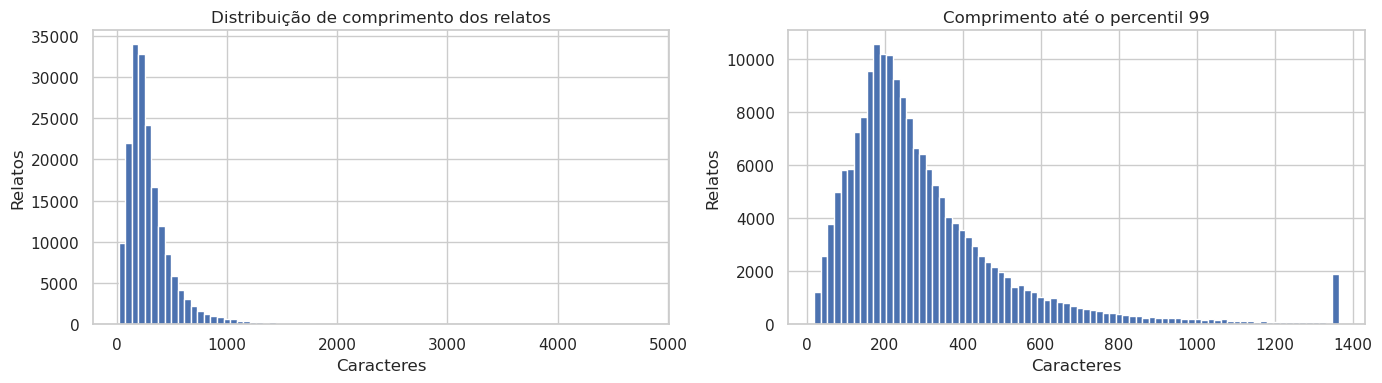

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["relato_chars"].hist(bins=80, ax=axes[0])
axes[0].set_title("Distribuição de comprimento dos relatos")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Relatos")

df["relato_chars"].clip(upper=df["relato_chars"].quantile(0.99)).hist(bins=80, ax=axes[1])
axes[1].set_title("Comprimento até o percentil 99")
axes[1].set_xlabel("Caracteres")
axes[1].set_ylabel("Relatos")

plt.tight_layout()

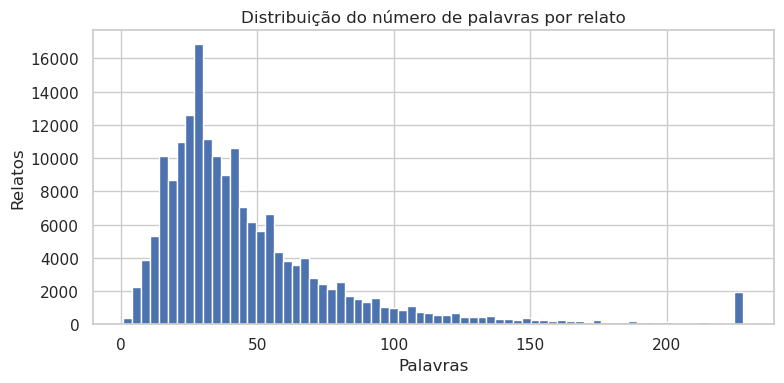

In [9]:
plt.figure(figsize=(8, 4))
df["relato_words"].clip(upper=df["relato_words"].quantile(0.99)).hist(bins=70)
plt.title("Distribuição do número de palavras por relato")
plt.xlabel("Palavras")
plt.ylabel("Relatos")
plt.tight_layout()

## Assuntos

Distribuição dos tipos de denúncia (`assunto`) no corpus mantido.

In [10]:
def value_counts_table(series: pd.Series, *, top_n: int = 30) -> pd.DataFrame:
    counts = series.fillna("").replace("", pd.NA).value_counts(dropna=False).head(top_n)
    table = counts.rename_axis("value").reset_index(name="count")
    table["share"] = table["count"] / len(series)
    return table

assunto_counts = value_counts_table(df["assunto"], top_n=50)
assunto_counts

,value,count,share
0,Tráfico de Drogas - Armas,141197,0.765324
1,Roubos em Geral,36680,0.198815
2,Homicídios,5754,0.031188
3,Roubo carga/ veículo,606,0.003285
4,Armas,256,0.001388


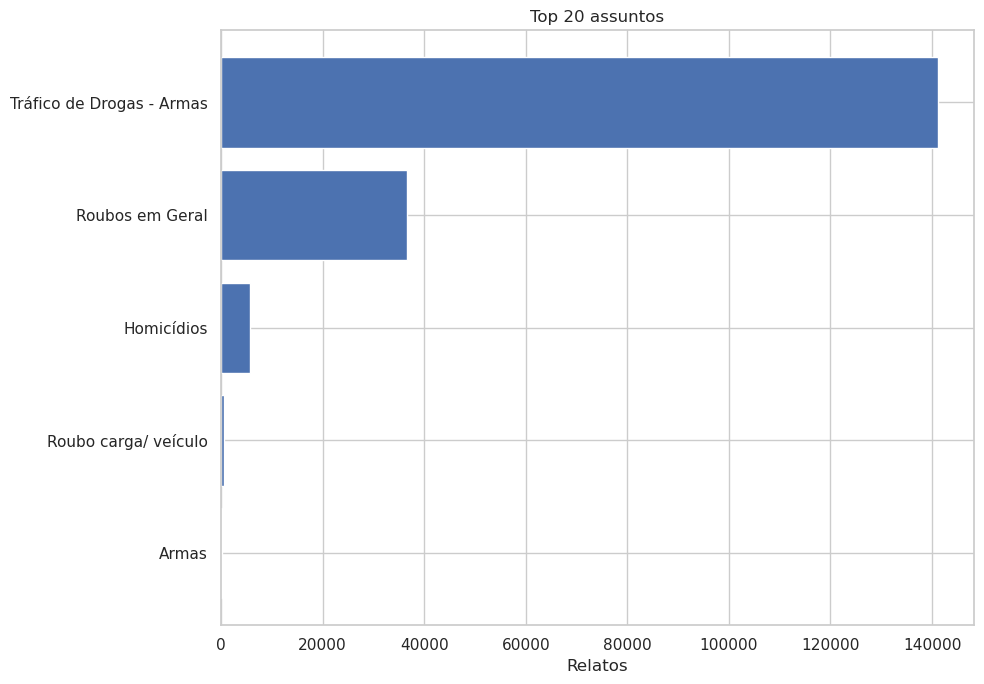

In [11]:
top_assuntos = assunto_counts.head(20).sort_values("count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_assuntos["value"].astype(str), top_assuntos["count"])
plt.title("Top 20 assuntos")
plt.xlabel("Relatos")
plt.ylabel("")
plt.tight_layout()

In [12]:
assunto_length = (
    df.groupby("assunto", dropna=False)
    .agg(
        rows=("relato", "size"),
        median_chars=("relato_chars", "median"),
        mean_chars=("relato_chars", "mean"),
        p90_chars=("relato_chars", lambda s: s.quantile(0.90)),
    )
    .sort_values("rows", ascending=False)
)
assunto_length.head(30)

,rows,median_chars,mean_chars,p90_chars
assunto,,,,
Tráfico de Drogas - Armas,141197,233.0,299.209934,539.0
Roubos em Geral,36680,288.0,333.688086,578.0
Homicídios,5754,301.0,432.180396,906.0
Roubo carga/ veículo,606,231.5,307.506601,581.0
Armas,256,243.0,354.226562,754.5


## Metadados geográficos

Cobertura dos campos de localização e distribuição dos valores mais frequentes.

In [13]:
geo_cols = ["logradouroLocal", "bairroLocal", "cidadeLocal", "pontodeReferenciaLocal"]

geo_coverage = []
for col in geo_cols:
    cleaned = df[col].fillna("").astype(str).str.strip() if col in df else pd.Series([], dtype=str)
    geo_coverage.append({
        "field": col,
        "non_empty": int((cleaned != "").sum()),
        "share_non_empty": float((cleaned != "").mean()) if len(cleaned) else math.nan,
        "distinct_non_empty": int(cleaned[cleaned != ""].nunique()) if len(cleaned) else 0,
    })

pd.DataFrame(geo_coverage)

,field,non_empty,share_non_empty,distinct_non_empty
0,logradouroLocal,158989,0.861762,42694
1,bairroLocal,171251,0.928225,8695
2,cidadeLocal,171333,0.928669,2502
3,pontodeReferenciaLocal,161289,0.874228,64446


In [14]:
for col in ["cidadeLocal", "bairroLocal", "logradouroLocal"]:
    print(f"\n=== {col} ===")
    display(value_counts_table(df[col].fillna("").astype(str).str.strip(), top_n=20))


=== cidadeLocal ===


,value,count,share
0,Mesquita,57113,0.309567
1,Rj,20792,0.112698
2,Rio de Janeiro,14825,0.080355
3,<NA>,13160,0.071331
4,Rio de janeiro,10493,0.056875
5,Nova Iguaçu,10015,0.054284
6,São Gonçalo,9364,0.050755
7,Nilópolis,5420,0.029378
8,Duque de Caxias,2986,0.016185
9,RJ,2603,0.014109



=== bairroLocal ===


,value,count,share
0,Coreia,23518,0.127474
1,Chatuba,17175,0.093093
2,<NA>,13242,0.071775
3,Juscelino,6114,0.033139
4,Centro,5872,0.031828
5,Alto Uruguai,3955,0.021437
6,Engenho da rainha,3177,0.017220
7,K11,2886,0.015643
8,Porto novo,1782,0.009659
9,Penha,1659,0.008992



=== logradouroLocal ===


,value,count,share
0,<NA>,25504,0.138238
1,Becos,5813,0.031508
2,Vielas,5301,0.028733
3,Rua Valinhos,1713,0.009285
4,Rua Caruaru,1432,0.007762
5,Rua carioca,1428,0.007740
6,Avenida Brasil,1359,0.007366
7,Rua da vala,1191,0.006456
8,Vias principais,1170,0.006342
9,Pontos estratégicos,1141,0.006185


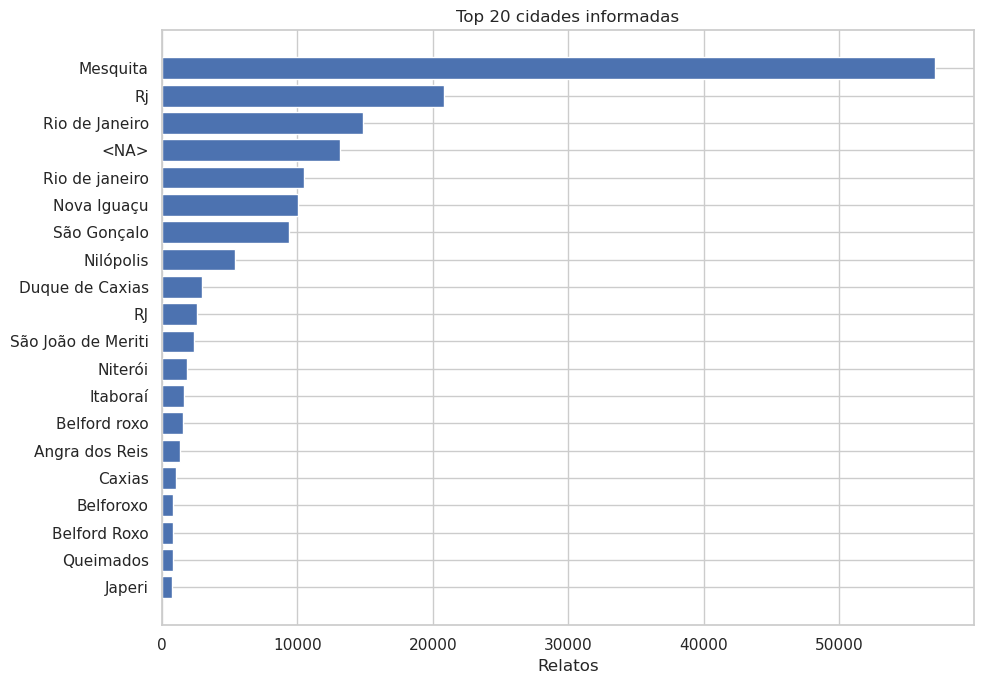

In [15]:
city_counts = value_counts_table(df["cidadeLocal"].fillna("").astype(str).str.strip(), top_n=20)
city_counts_plot = city_counts.sort_values("count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(city_counts_plot["value"].astype(str), city_counts_plot["count"])
plt.title("Top 20 cidades informadas")
plt.xlabel("Relatos")
plt.ylabel("")
plt.tight_layout()

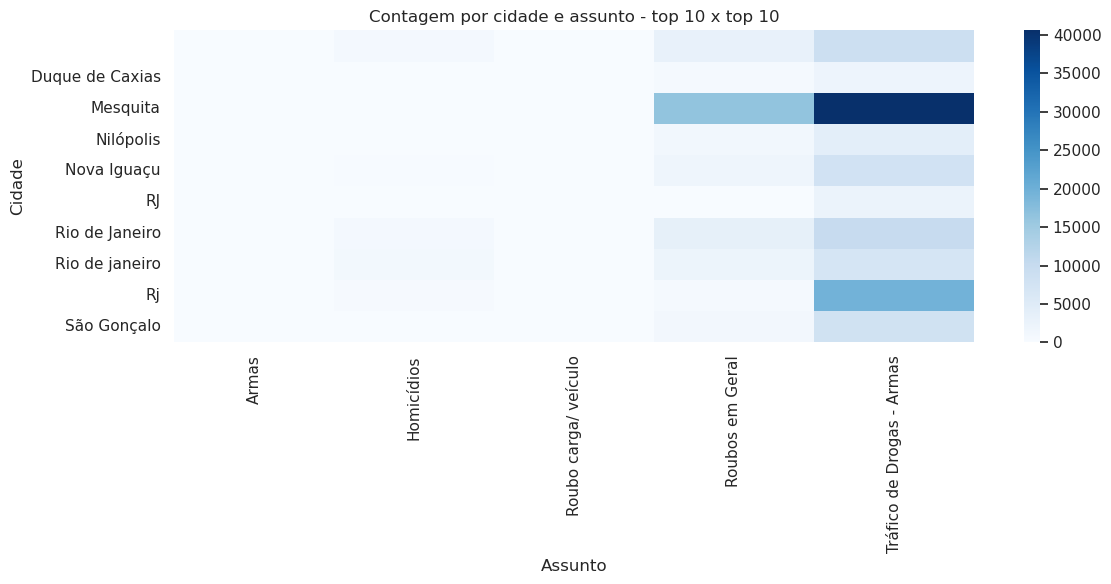

In [16]:
top_cities = df["cidadeLocal"].fillna("").astype(str).str.strip().value_counts().head(10).index
top_subjects = df["assunto"].fillna("").astype(str).str.strip().value_counts().head(10).index

city_subject = pd.crosstab(
    df["cidadeLocal"].fillna("").astype(str).str.strip(),
    df["assunto"].fillna("").astype(str).str.strip(),
)
city_subject_top = city_subject.loc[city_subject.index.intersection(top_cities), city_subject.columns.intersection(top_subjects)]

if sns is not None:
    plt.figure(figsize=(12, 6))
    sns.heatmap(city_subject_top, cmap="Blues", annot=False)
    plt.title("Contagem por cidade e assunto - top 10 x top 10")
    plt.xlabel("Assunto")
    plt.ylabel("Cidade")
    plt.tight_layout()
else:
    display(city_subject_top)

## Sinais de qualidade textual

Essas estatísticas ajudam a reportar características do corpus e a encontrar casos que podem merecer inspeção manual.

In [17]:
quality_stats = df[["uppercase_ratio", "digit_ratio", "punctuation_ratio"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).T
quality_stats

,count,mean,std,min,50%,75%,90%,95%,99%,max
uppercase_ratio,184493.0,0.060483,0.141256,0.0,0.033557,0.052863,0.075000,0.103448,0.989752,1.00000
digit_ratio,184493.0,0.005945,0.012268,0.0,0.000000,0.007905,0.015625,0.024096,0.055556,0.47500
punctuation_ratio,184493.0,0.017705,0.017337,0.0,0.016000,0.024510,0.034314,0.042593,0.079365,0.47619


In [18]:
quality_flags = pd.DataFrame({
    "metric": ["has_url", "uppercase_ratio >= 0.5", "digit_ratio >= 0.1", "relato_lines >= 5"],
    "count": [
        int(df["has_url"].sum()),
        int((df["uppercase_ratio"] >= 0.5).sum()),
        int((df["digit_ratio"] >= 0.1).sum()),
        int((df["relato_lines"] >= 5).sum()),
    ],
})
quality_flags["share"] = quality_flags["count"] / len(df)
quality_flags

,metric,count,share
0,has_url,368,0.001995
1,uppercase_ratio >= 0.5,4350,0.023578
2,digit_ratio >= 0.1,456,0.002472
3,relato_lines >= 5,73805,0.400042


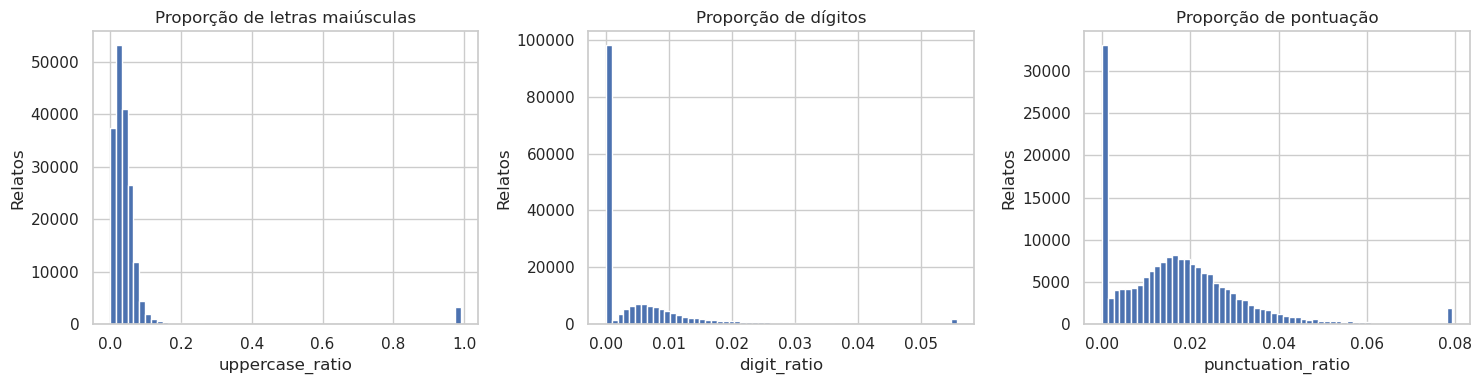

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["uppercase_ratio", "digit_ratio", "punctuation_ratio"],
    ["Proporção de letras maiúsculas", "Proporção de dígitos", "Proporção de pontuação"],
):
    df[col].clip(upper=df[col].quantile(0.99)).hist(bins=60, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Relatos")
plt.tight_layout()

## Vocabulário e termos frequentes

Esta seção usa tokenização simples por regex. Ela não substitui uma análise linguística, mas é útil para uma visão inicial do domínio.

In [20]:
STOPWORDS_PT = {
    "a", "o", "as", "os", "um", "uma", "uns", "umas", "de", "da", "do", "das", "dos",
    "em", "no", "na", "nos", "nas", "para", "por", "com", "sem", "e", "ou", "que",
    "se", "ao", "aos", "à", "às", "pra", "pro", "pela", "pelo", "pelas", "pelos",
    "esta", "está", "estao", "estão", "ser", "são", "foi", "tem", "dos", "das",
    "ele", "ela", "eles", "elas", "isso", "esse", "essa", "esses", "essas", "aqui",
    "muito", "muita", "muitos", "muitas", "mais", "menos", "todo", "toda", "todos", "todas",
}

def strip_accents(text: str) -> str:
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))

def tokenize(text: str) -> list[str]:
    normalized = strip_accents(text.lower())
    tokens = WORD_RE.findall(normalized)
    return [tok for tok in tokens if len(tok) >= 3 and tok not in STOPWORDS_PT and not tok.isdigit()]

token_counter = Counter()
bigram_counter = Counter()
for text in df["relato"]:
    tokens = tokenize(text)
    token_counter.update(tokens)
    bigram_counter.update(zip(tokens, tokens[1:]))

top_terms = pd.DataFrame(token_counter.most_common(50), columns=["term", "count"])
top_terms.head(30)

,term,count
0,rua,274883
1,motos,97243
2,drogas,91118
3,roubadas,81711
4,fuzis,65831
5,bandidos,56456
6,escopetas,53840
7,cargas,51954
8,carros,49598
9,armados,49065


In [21]:
top_bigrams = pd.DataFrame(
    [(" ".join(pair), count) for pair, count in bigram_counter.most_common(50)],
    columns=["bigram", "count"],
)
top_bigrams.head(30)

,bigram,count
0,escopetas fuzis,50255
1,cargas roubadas,48105
2,fortemente armados,34417
3,motos roubadas,31633
4,andando fortemente,30081
5,motos taxis,27045
6,municoes escopetas,25216
7,carros roubados,24580
8,radinhos municoes,23444
9,revolveres escopetas,21943


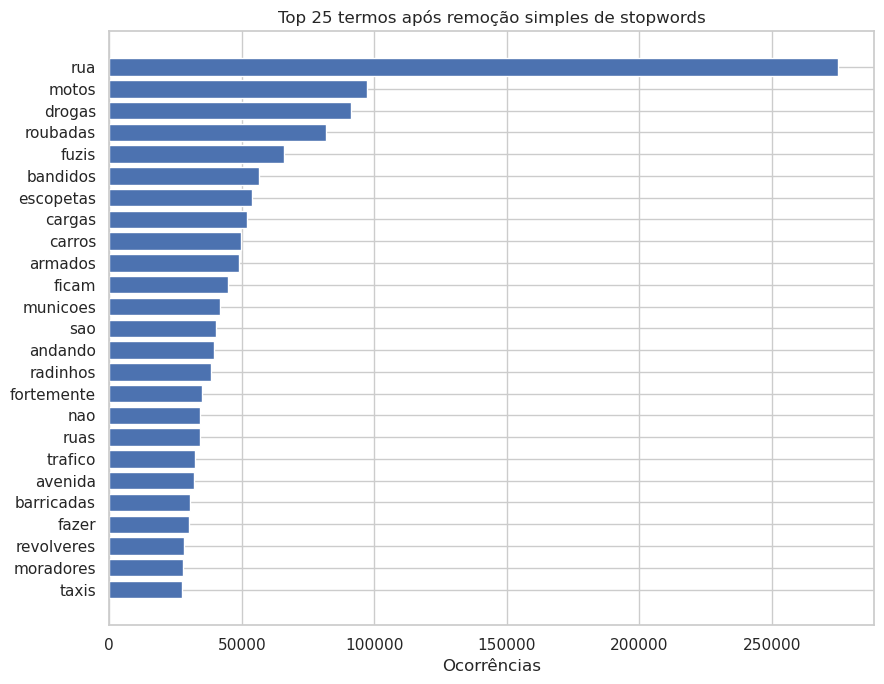

In [22]:
plot_terms = top_terms.head(25).sort_values("count", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_terms["term"], plot_terms["count"])
plt.title("Top 25 termos após remoção simples de stopwords")
plt.xlabel("Ocorrências")
plt.ylabel("")
plt.tight_layout()

## Amostras para inspeção qualitativa

In [23]:
sample_cols = ["assunto", "cidadeLocal", "bairroLocal", "logradouroLocal", "relato_chars", "relato"]
df.sample(10, random_state=42)[sample_cols]

,assunto,cidadeLocal,bairroLocal,logradouroLocal,relato_chars,relato
141401,Tráfico de Drogas - Armas,Mesquita,Chatuba,Rua Elizeu de alvarenga,153,Uma ação tiragem 53dp após dados de investigação \n\nChatuba facção cv \n\nRua Elizeu de alvarenga \n\nRua magno Carvalho \n\nRua Lídia \n\nRua Rodon Go...
120933,Homicídios,Rio de janeiro,Comendador soares,Rua São João 131,233,Homem que matou um rapaz conhecido como caroço no bairro comendador soares. O assassino se chama John Cristian Fidelis tem uma tatuagem escrito Cristiane e ...
54085,Tráfico de Drogas - Armas,Mesquita,Chatuba,Rua Fazenda,178,Policiais militares do gat 20bpm com policiais militares do dpo chatuba fazer uma boa incursão\n\nFavela Chatuba facção cv\n\nRua Fazenda Escadao\nRua Ináci...
151364,Tráfico de Drogas - Armas,Duque de Caxias,Parque Paulista,Rua Leopoldo Migues,772,O abandono da polícia militar precisamente o 15BPM e nítido no bairro Parque Paulista.\nOnde atualmente e conhecido como parque paz.\nTraficantes oriundos d...
180852,Roubos em Geral,,,,183,Uma Boa operação delegacia de mesquita na região Vila norma facção cv através de intensa investigação Rua Cachoeira Rua Thompson flores Rua Álvaro L...
147164,Tráfico de Drogas - Armas,Angra dos Reis,Areal,Travessa Lavrador João Alves Folho,281,"Novo chefe do tráfico, residindo próximo às casinhas do Areal. Foi solto da prisão a pouco tempo e está botando terror no bairro. Marido de uma moça loira, ..."
131348,Tráfico de Drogas - Armas,São Gonçalo,Porto novo,Travessa Lais costa,316,"Traficantes da favela do Pombal em São Gonçalo,coordenado por ranger segurança de Rabicó e braço direito de Biel estão organizando um baile funk na comunida..."
142447,Tráfico de Drogas - Armas,Mesquita,Coreia,Rua carioca bar Jorge,316,Uma ação bons planejamentos de investigação \n\nEquipe Aib tem drogas radinhos munições escopetas fuzis motos sem placas motos táxis carros roubados...
154152,Tráfico de Drogas - Armas,São Pedro da Aldeia,Praia Linda,Av Maria Dulce e arredores,560,Feriado chegando e nosso inferno só piora. Nosso bairro e nossa rua estão dominados pelos bandidos. Moradores sendo expulsos e mudando de suas casas e nada ...
141087,Tráfico de Drogas - Armas,Rio das ostras,Liberdade,Rua sao jorge,187,Dois elementos traficando desde de manha cedo na rua. E quando a policia passa eles se escondem no portao branco do numero 06\nWaguinho e felipe. Vendem dro...


In [24]:
df.nlargest(10, "relato_chars")[sample_cols]

,assunto,cidadeLocal,bairroLocal,logradouroLocal,relato_chars,relato
172765,Tráfico de Drogas - Armas,Nova Iguaçu,Jardim Alvorada,Estrada cambucas,4774,O bairro jardim Alvorada está tomado pelo tráfico de drogas e grande o movimento das drogas na estrada cambucas quase 100% do bairro está participando na om...
91880,Homicídios,Volta Redonda,Eucaliptal e Jardim Tiradentes,Rua Baltazar de Souza (essa rua é no Eucaliptal),4656,"Trata-se do homicídio de Eugênio Belarmino da Silva ocorrido em 07/08/2018 em seu Bar do Cabecinha, que era esse apelido (""Cabecinha"") que era tratado esse ..."
52301,Tráfico de Drogas - Armas,Duque de Caxias,Vila ideal,Vila ideal,4542,"**Informações precisas e valiosas.**\nApós a morte do traficante ""Charlinho do Lixão"", que comandava comunidades em Duque de Caxias, um traficante antigo de..."
91871,Roubos em Geral,Rio de Janeiro,Grajaú,Rua Uberaba,4493,Boa tarde.\nHá 2 dias fui vítima de um golpe armado por 3 homens. Até agora não acredito que fui enrolada por uma história tão absurda! Estou com vergonha e...
178213,Roubos em Geral,,,,4493,Boa tarde. Há 2 dias fui vítima de um golpe armado por 3 homens. Até agora não acredito que fui enrolada por uma história tão absurda! Estou com vergonha e ...
180798,Tráfico de Drogas - Armas,,,,4491,Indivíduos armados praticando Tráfico de drogas e aliciando crianças para cometer o mesmo crime na esquina da Rua Murilo dos Santos Conceição com a Rua Dr. ...
180399,Tráfico de Drogas - Armas,,,,4480,Indivíduos armados praticando Tráfico de drogas e aliciando crianças para cometer o mesmo crime na esquina da Rua Murilo dos Santos Conceição com a Rua Dr. ...
111396,Tráfico de Drogas - Armas,Saquarema,Diversos,Diversos,4274,"Passo para informar sobre a existência de uma quadrilha de traficantes que atua em diversas localidades da cidade de Saquarema, sendo certo de que a polícia..."
44195,Tráfico de Drogas - Armas,rio de janeiro,vargem grande,rua sem efeito,4257,"Há décadas no estado do Rio circula um abastecedor de drogas e armas para favelas. Nome Carlos Adriano Batista de Oliveira, vulgo Isac, idade + - 42 anos, ..."
69536,Homicídios,Rio de janeiro,Iguaba grande,Sapeatiba mirin,4252,Uma mulhe da Facção do TCP da ilha do governado mandou me matar com meu tio o PE ak em Iguaba grande e sapeatiba mirim RJ e pedi ajuda ao meu tio que mora n...


In [25]:
df.nsmallest(10, "relato_chars")[sample_cols]

,assunto,cidadeLocal,bairroLocal,logradouroLocal,relato_chars,relato
601,Armas,Itaborai,Manilha,Rua k com rua E. Granjas cabuco,20,Muita arma no local.
5449,Roubos em Geral,Rio de Janeiro,Irajá,Rua Fernandes Gusnão,20,"Furto de luz "" GATO"""
5960,Tráfico de Drogas - Armas,Rio de Janeiro,Tijuca,Rua Esmeralda,20,Traficante de drogas
7939,Tráfico de Drogas - Armas,Duque de Caxias,Jardim Panamá,Rua Diogo Camarao,20,Drogas e funk na rua
13401,Roubos em Geral,São Gonçalo,Rio do Ouro,Rua Renato Girandi,20,Furto energia (gato)
21927,Roubos em Geral,Nova Iguaçu,Recreio paço da Marambaia,Rua Miguel Ferreira Lopes,20,Assalto a mão armada
28302,Tráfico de Drogas - Armas,Rio de janeiro,Inhoaiba,Rua progresso de ana Gonzaga lote 30 lote 6,20,Um suposto miliciano
29735,Tráfico de Drogas - Armas,Itatiaia,Vila esperança,Rua capitão João ferreira,20,Tráfico já conhecido
34582,Tráfico de Drogas - Armas,Rio de janeiro,Inhoaiba,Rua progresso de ana Gonzaga lote 5 quadra 29,20,Traficanto de drogas
36646,Tráfico de Drogas - Armas,Angra dos reis,Belem,Rua sao mathues,20,Envolvido no trafico


## Tabelas-resumo para o paper

A célula abaixo reúne métricas agregadas em uma única tabela. Ajuste ou exporte conforme a redação da seção de dataset.

In [26]:
paper_summary = pd.DataFrame([{
    "reports": len(df),
    "distinct_assuntos": df["assunto"].fillna("").replace("", pd.NA).nunique(dropna=True),
    "distinct_cities": df["cidadeLocal"].fillna("").astype(str).str.strip().replace("", pd.NA).nunique(dropna=True),
    "median_chars": df["relato_chars"].median(),
    "mean_chars": df["relato_chars"].mean(),
    "p90_chars": df["relato_chars"].quantile(0.90),
    "median_words": df["relato_words"].median(),
    "mean_words": df["relato_words"].mean(),
    "share_with_city": df["cidadeLocal"].fillna("").astype(str).str.strip().ne("").mean(),
    "share_with_bairro": df["bairroLocal"].fillna("").astype(str).str.strip().ne("").mean(),
    "share_with_logradouro": df["logradouroLocal"].fillna("").astype(str).str.strip().ne("").mean(),
    "share_with_url": df["has_url"].mean(),
}])
paper_summary.T.rename(columns={0: "value"})

,value
reports,184493.000000
distinct_assuntos,5.000000
distinct_cities,2502.000000
median_chars,245.000000
mean_chars,310.315410
p90_chars,559.000000
median_words,37.000000
mean_words,48.367429
share_with_city,0.928669
share_with_bairro,0.928225


In [27]:
OUT_DIR = Path("../artifacts/eda/large_sanitized")
OUT_DIR.mkdir(parents=True, exist_ok=True)

paper_summary.to_csv(OUT_DIR / "paper_summary.csv", index=False)
assunto_counts.to_csv(OUT_DIR / "assunto_counts.csv", index=False)
length_stats.to_csv(OUT_DIR / "length_stats.csv")
top_terms.to_csv(OUT_DIR / "top_terms.csv", index=False)
top_bigrams.to_csv(OUT_DIR / "top_bigrams.csv", index=False)

print(f"Tabelas salvas em: {OUT_DIR.resolve()}")

Tabelas salvas em: /home/ebezerra/ailab/nerdd/artifacts/eda/large_sanitized
